## Imports

In [1]:
import pandas as pd
import numpy as np
import os

## Load Features Data

In [2]:
PROCESSED_PATH = os.path.join("data", 'processed')
processed_file_path = os.path.join(PROCESSED_PATH, "features.csv")

features = pd.read_csv(processed_file_path, index_col=0, parse_dates=True)
features.head()

,SPY_vol_20,SPY_price_ma50,SPY_price_ma200,SPY_drawdown,VIX_level,TLT_ret_20,GLD_ret_20,SPY_ret_5,SPY_ret_20
Date,,,,,,,,,
2005-10-17,0.102647,0.979883,0.999383,-0.040915,14.670000,-0.018791,0.021838,0.004301,-0.032334
2005-10-18,0.105068,0.969958,0.988602,-0.051302,15.330000,-0.020250,0.016656,-0.005150,-0.034658
2005-10-19,0.119602,0.986595,1.004947,-0.035520,13.500000,-0.028844,-0.015300,0.019404,-0.009346
2005-10-20,0.133068,0.970037,0.987199,-0.052510,16.110001,-0.025324,-0.008197,0.002044,-0.030245
2005-10-21,0.134228,0.974659,0.991018,-0.048807,16.129999,-0.008850,0.005186,-0.004551,-0.027256


## Train-Test Split

In [3]:
features = features.sort_index()

split_idx = int(len(features) * 0.7)

train = features.iloc[:split_idx]
test = features.iloc[split_idx:]

In [4]:
X_raw = features.copy()

## Normalization

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(train)
X_test = scaler.transform(test)

In [6]:
X = scaler.transform(X_raw)

In [7]:
X = pd.DataFrame(
    X,
    index=features.index,
    columns=features.columns
)

In [8]:

X_train = pd.DataFrame(X_train, index=train.index, columns=train.columns)
X_test = pd.DataFrame(X_test, index=test.index, columns=test.columns)

## Find Optimal K using Elbow Method

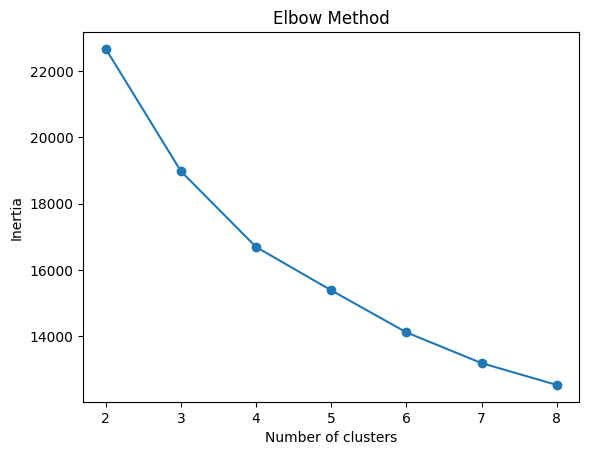

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_train)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

## K=4 seems plausible

## Lets check using Silhouette method

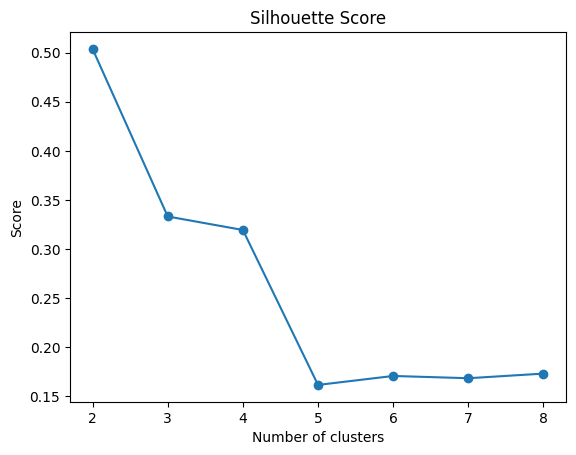

In [10]:
from sklearn.metrics import silhouette_score

scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train)
    score = silhouette_score(X_train, labels)
    scores.append(score)

plt.plot(K_range, scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of clusters")
plt.ylabel("Score")
plt.show()

## For K=2, silhouette score is highest

## Lets Visualize Clusters

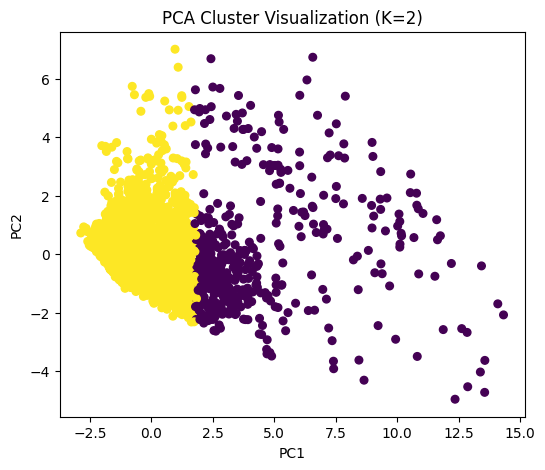

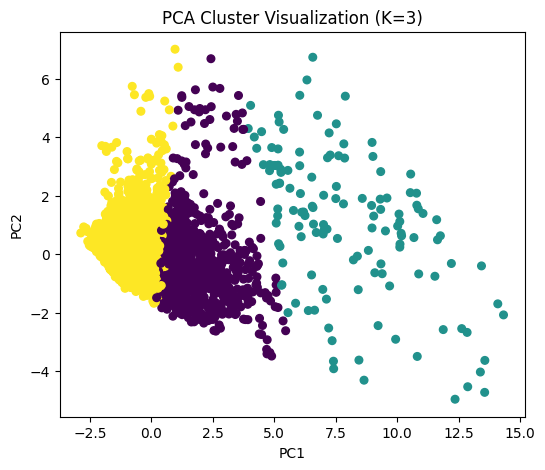

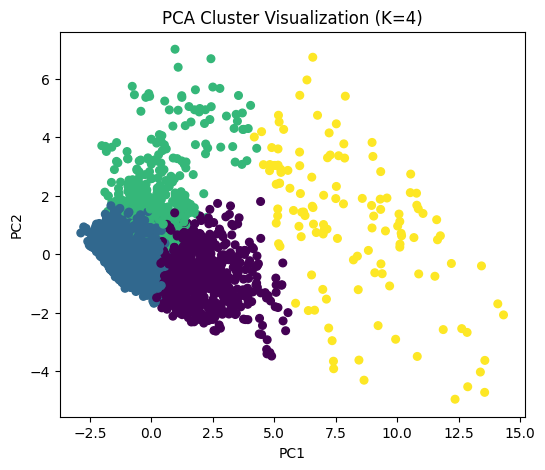

In [11]:
from sklearn.decomposition import PCA

def plot_clusters(X, k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(6,5))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', s=30)
    plt.title(f"PCA Cluster Visualization (K={k})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

plot_clusters(X_train, 2)
plot_clusters(X_train, 3)
plot_clusters(X_train, 4)

## K=3,4 does not produce well separated clusters, there is lot of overlap. We go with K=2.

In [12]:
from hmmlearn.hmm import GaussianHMM

model = GaussianHMM(
    n_components=2,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

model.fit(X_train)

,n_components,2
,covariance_type,'full'
,random_state,42
,n_iter,1000
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1


In [13]:
train_regimes = model.predict(X_train)
train["regime"] = train_regimes

test_regimes = model.predict(X_test)
test["regime"] = test_regimes

In [14]:
train["regime"].value_counts(normalize=True)

regime
1    0.579252
0    0.420748
Name: proportion, dtype: float64

In [15]:
test["regime"].value_counts(normalize=True)

regime
0    0.603979
1    0.396021
Name: proportion, dtype: float64

## Lets Evaluate Regimes

In [16]:
cols = [
    "SPY_ret_20",
    "SPY_vol_20",
    "VIX_level",
    "SPY_drawdown"
]

train.groupby("regime")[cols].mean()

,SPY_ret_20,SPY_vol_20,VIX_level,SPY_drawdown
regime,,,,
0,-0.002509,0.225993,25.581759,-0.176566
1,0.014047,0.103143,14.003663,-0.012020


In [17]:
test.groupby("regime")[cols].mean()

,SPY_ret_20,SPY_vol_20,VIX_level,SPY_drawdown
regime,,,,
0,0.011606,0.200716,23.360298,-0.08235
1,0.021268,0.112218,16.382674,-0.00911


| Regime | Meaning                        |
| ------ | ------------------------------ |
| 1      | Low vol bull market           |    |
|  0     | Crisis / high volatility shock |


In [18]:
features["regime"] = model.predict(X)

In [19]:
features = features.sort_index()

In [20]:
windows = {
    "2008_crisis": ("2008-01-01", "2009-06-01"),
    "covid_crash": ("2020-02-01", "2020-06-01"),
    "inflation_2022": ("2022-01-01", "2022-10-01")
}

In [21]:
def regime_stats(start, end):
    subset = features.loc[start:end]
    return subset["regime"].value_counts(normalize=True).sort_index()

In [22]:
for name, (start, end) in windows.items():
    print(f"\n{name}")
    print(regime_stats(start, end))


2008_crisis
regime
0    1.0
Name: proportion, dtype: float64

covid_crash
regime
0    0.831325
1    0.168675
Name: proportion, dtype: float64

inflation_2022
regime
0    0.941489
1    0.058511
Name: proportion, dtype: float64


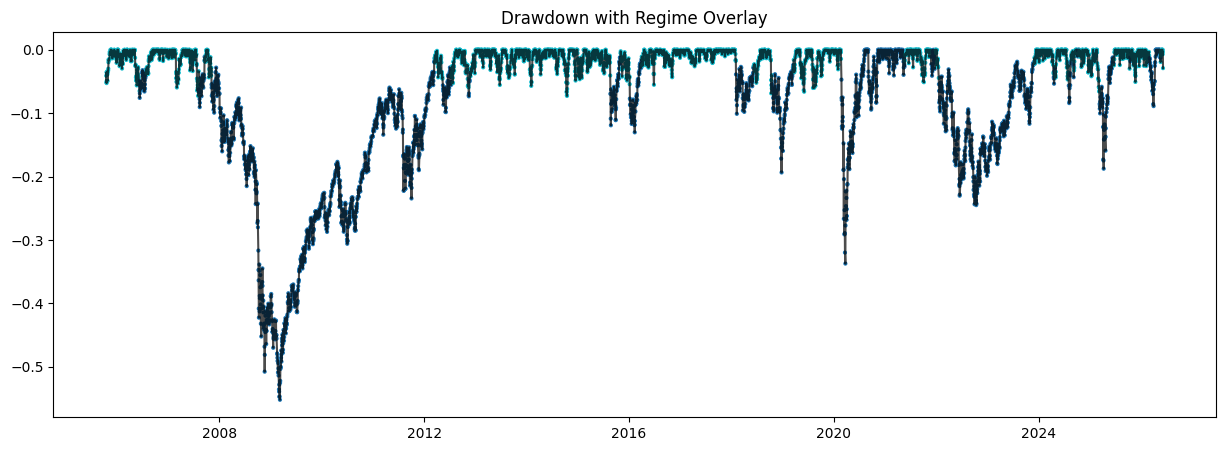

In [23]:
plt.figure(figsize=(15,5))

plt.plot(features.index, features["SPY_drawdown"], color="black", alpha=0.7)

plt.scatter(
    features.index,
    features["SPY_drawdown"],
    c=features["regime"],
    cmap="tab10",
    s=4
)

plt.title("Drawdown with Regime Overlay")
plt.show()

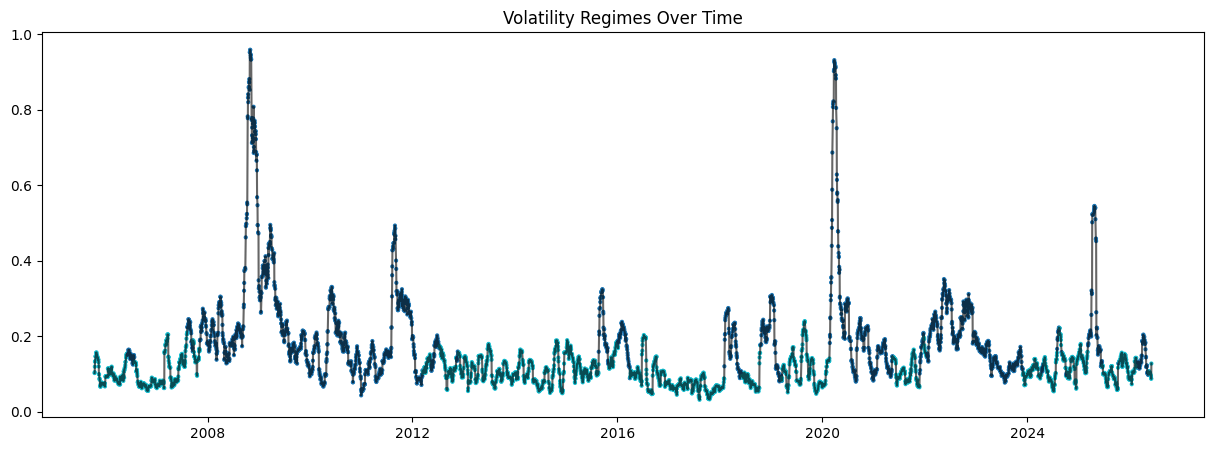

In [24]:
plt.figure(figsize=(15,5))

plt.plot(features.index, features["SPY_vol_20"], color="black", alpha=0.6)

plt.scatter(
    features.index,
    features["SPY_vol_20"],
    c=features["regime"],
    cmap="tab10",
    s=4
)

plt.title("Volatility Regimes Over Time")
plt.show()

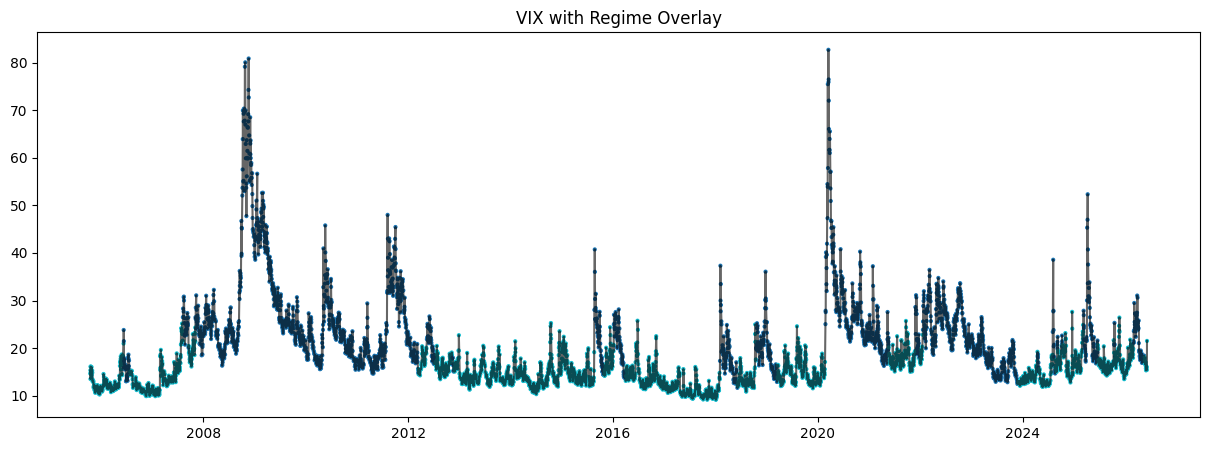

In [25]:
plt.figure(figsize=(15,5))

plt.plot(features.index, features["VIX_level"], color="black", alpha=0.6)

plt.scatter(
    features.index,
    features["VIX_level"],
    c=features["regime"],
    cmap="tab10",
    s=4
)

plt.title("VIX with Regime Overlay")
plt.show()

<Axes: title={'center': 'Regime Frequency Distribution'}, xlabel='regime'>

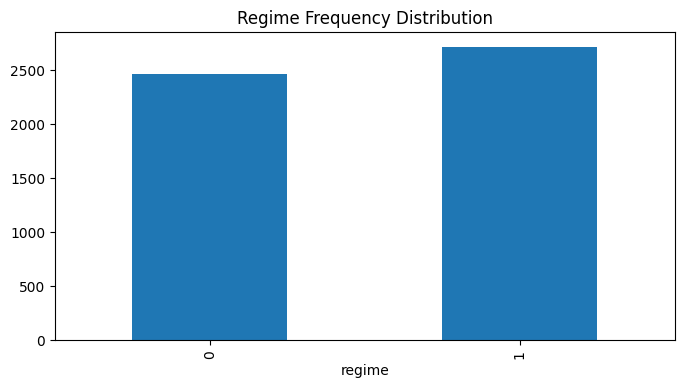

In [26]:
features["regime"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,4),
    title="Regime Frequency Distribution"
)

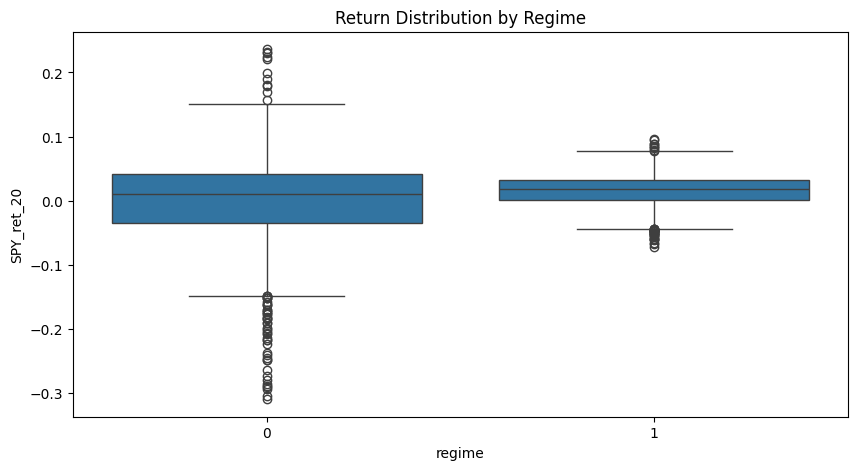

In [27]:
import seaborn as sns

plt.figure(figsize=(10,5))

sns.boxplot(
    x="regime",
    y="SPY_ret_20",
    data=features
)

plt.title("Return Distribution by Regime")
plt.show()

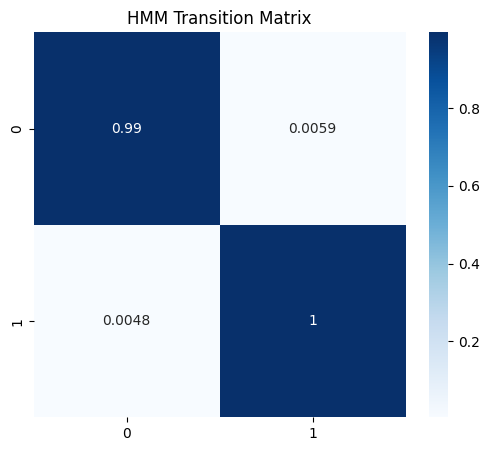

In [28]:
import seaborn as sns

transmat = model.transmat_

plt.figure(figsize=(6,5))

sns.heatmap(
    transmat,
    annot=True,
    cmap="Blues"
)

plt.title("HMM Transition Matrix")
plt.show()

## Backtest

In [29]:
probs = model.predict_proba(X)

In [30]:
p_risk_on = probs[:, 1]
p_risk_off = probs[:, 0]

In [31]:
features["position"] = np.clip(p_risk_on * 2, 0, 2)

In [32]:
features["turnover"] = features["position"].diff().abs()

tcost = 0.0005   # 5 bps per unit turnover
features["transaction_cost"] = tcost * features["turnover"]

In [33]:

df = pd.read_csv("data/raw/market_prices.csv", index_col=0, parse_dates=True)

In [34]:
df.index.equals(features.index)

False

In [35]:
features = features.join(df[["SPY"]], how="inner")

In [36]:
features["SPY_ret"] = features["SPY"].pct_change()
features = features.dropna()

In [37]:
features["strategy_return_tc"] = (
    features["position"].shift(1) * features["SPY_ret"]
    - features["transaction_cost"]
)

In [38]:
features["cum_market"] = (1 + features["SPY_ret"]).cumprod()
features["cum_strategy_tc"] = (1 + features["strategy_return_tc"]).cumprod()


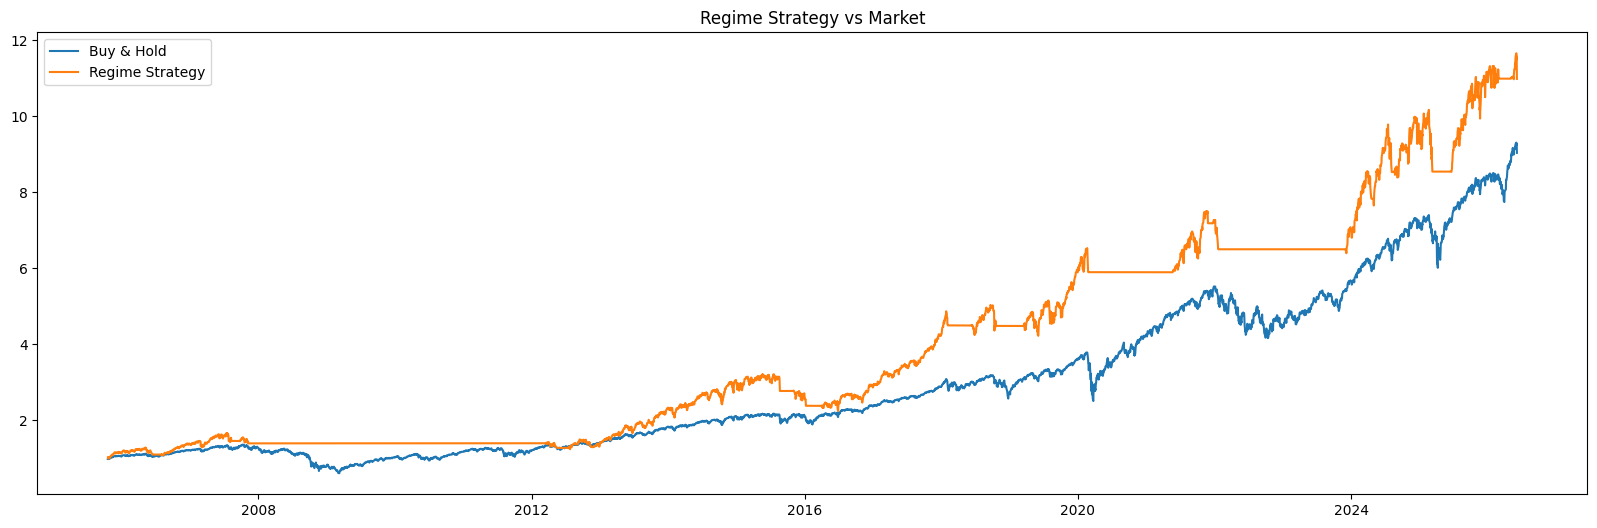

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,6))

plt.plot(features.index, features["cum_market"], label="Buy & Hold")
plt.plot(features.index, features["cum_strategy_tc"], label="Regime Strategy")

plt.legend()
plt.title("Regime Strategy vs Market")
plt.show()

In [40]:
import numpy as np

def sharpe(returns):
    return round(np.sqrt(252) * returns.mean() / returns.std(),2)

print("Market Sharpe:", sharpe(features["SPY_ret"]))
print("Strategy Sharpe:", sharpe(features["strategy_return_tc"]))

Market Sharpe: 0.65
Strategy Sharpe: 0.79


In [41]:
import numpy as np

def sortino_ratio(returns, target=0):
    downside = returns[returns < target]
    downside_std = np.sqrt(np.mean(downside**2))
    
    if downside_std == 0:
        return np.nan
    
    return round(np.sqrt(252) * returns.mean() / downside_std,2)

print("Market Sortino:", sortino_ratio(features["SPY_ret"]))
print("Strategy Sortino:", sortino_ratio(features["strategy_return_tc"]))

Market Sortino: 0.61
Strategy Sortino: 0.8


In [42]:
def max_drawdown(cum_returns):
    peak = cum_returns.cummax()
    dd = (cum_returns - peak) / peak
    return round(dd.min(),2)

print("Market DD:", max_drawdown(features["cum_market"]))
print("Strategy DD:", max_drawdown(features["cum_strategy_tc"]))

Market DD: -0.55
Strategy DD: -0.3


In [44]:
market_total_return = features["cum_market"].iloc[-1] - 1
strategy_total_return = features["cum_strategy_tc"].iloc[-1] - 1

print("Market Total Return:", round(market_total_return, 2))
print("Strategy Total Return:", round(strategy_total_return, 2))

Market Total Return: 8.04
Strategy Total Return: 9.99
